# Cell 1: Install Required Libraries

In [ ]:
!pip install PyWavelets scipy scikit-image opencv-python --quiet

# Cell 2: Import Libraries

In [ ]:
import os
import cv2
import math
import numpy as np
import matplotlib.pyplot as plt

import pywt

from scipy.fftpack import dct, idct
from scipy.ndimage import convolve
from scipy.ndimage import median_filter
from scipy.ndimage import maximum_filter
from scipy.ndimage import minimum_filter
from scipy.ndimage import gaussian_filter

from skimage.metrics import peak_signal_noise_ratio as psnr

plt.rcParams["figure.figsize"] = (12,6)

# Cell 3: Read All Images Automatically

In [ ]:
folder = "."

images = {}

for file in sorted(os.listdir(folder)):
    if file.lower().endswith((".jpg", ".jpeg", ".png")):
        img = cv2.imread(os.path.join(folder, file),
                         cv2.IMREAD_GRAYSCALE)

        images[file] = img

print(images.keys())

dict_keys(['image1.jpg', 'image2.jpg', 'image3.jpg', 'image4.png'])


# Cell 4: Show All Images

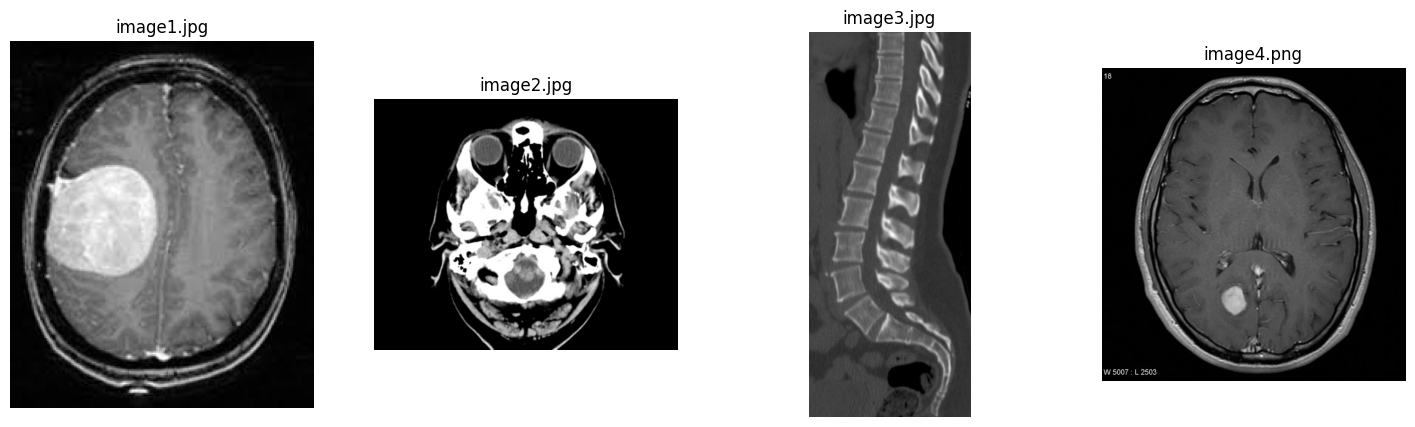

In [ ]:
fig, ax = plt.subplots(1, len(images), figsize=(18,5))

for i,(name,img) in enumerate(images.items()):
    ax[i].imshow(img,cmap='gray')
    ax[i].set_title(name)
    ax[i].axis("off")

plt.show()

# Cell 5: PSNR Function

In [ ]:
def calculate_psnr(original, compressed):
    return psnr(original, compressed, data_range=255)

# Cell 6: Compression Ratio Function

In [ ]:
def compression_ratio(original, compressed):

    original_size = original.nbytes
    compressed_size = compressed.nbytes

    return original_size / compressed_size

# Cell 7: 2D DCT

In [ ]:
def dct2(img):
    return dct(dct(img.T, norm='ortho').T, norm='ortho')


def idct2(coeff):
    return idct(idct(coeff.T, norm='ortho').T, norm='ortho')

# Cell 8: DCT Compression

In [ ]:
def dct_compress(image, keep=0.1):

    coeff = dct2(image)

    h,w = coeff.shape

    mask = np.zeros_like(coeff)

    mask[:int(h*keep), :int(w*keep)] = 1

    coeff = coeff * mask

    recovered = idct2(coeff)

    recovered = np.clip(recovered,0,255).astype(np.uint8)

    return recovered

# Cell 9: Apply DCT to All Images

In [ ]:
dct_results = {}

for name,img in images.items():

    recovered = dct_compress(img)

    dct_results[name] = recovered

# Cell 10: Display Input and Output Side-by-Side

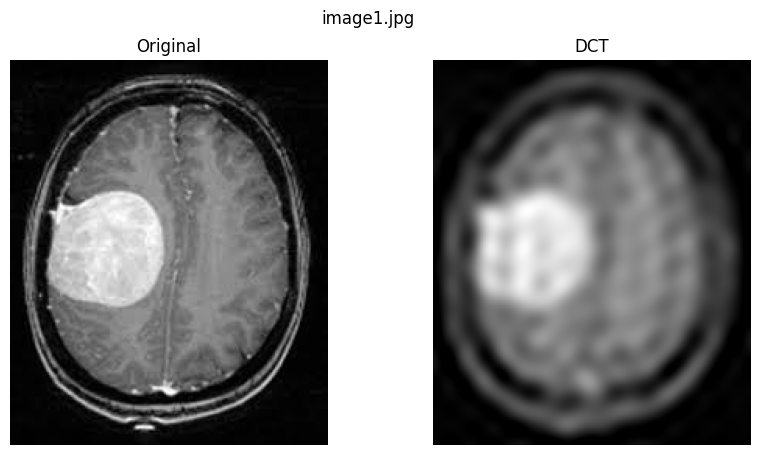

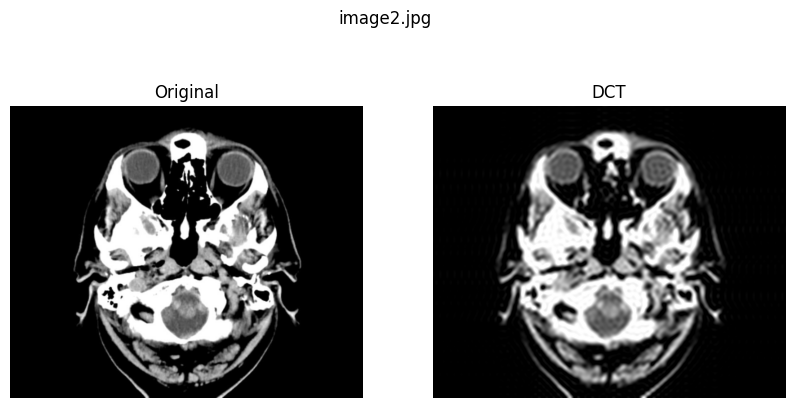

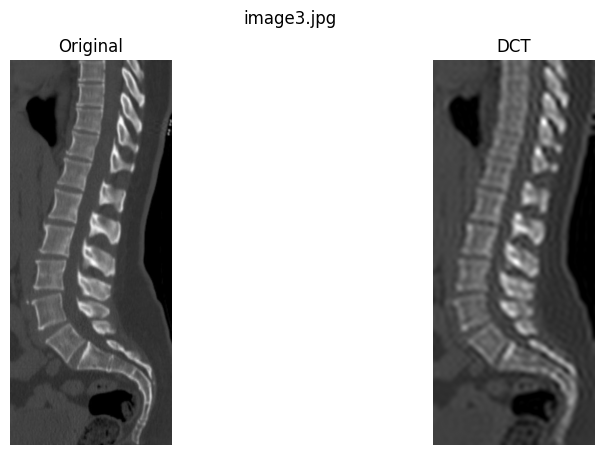

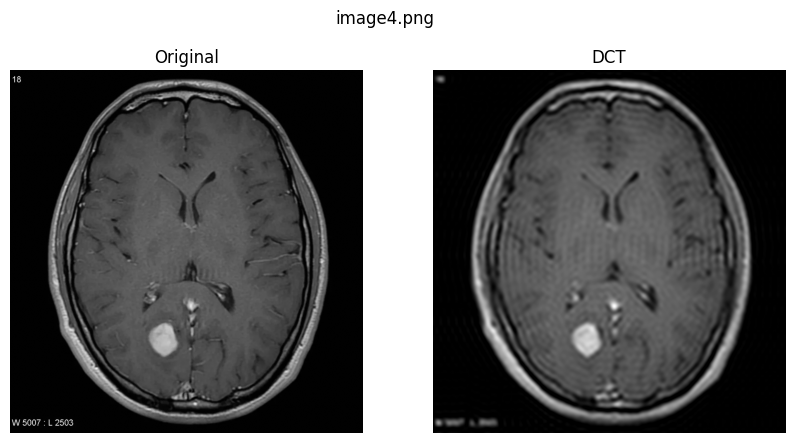

In [ ]:
for name in images:

    fig,ax = plt.subplots(1,2,figsize=(10,5))

    ax[0].imshow(images[name],cmap='gray')
    ax[0].set_title("Original")
    ax[0].axis("off")

    ax[1].imshow(dct_results[name],cmap='gray')
    ax[1].set_title("DCT")
    ax[1].axis("off")

    plt.suptitle(name)

    plt.show()

# Cell 11: DCT PSNR and Compression Ratio

In [ ]:
print("DCT Results\n")

for name in images:

    p = calculate_psnr(images[name], dct_results[name])

    cr = compression_ratio(images[name], dct_results[name])

    print(name)

    print("PSNR =", round(p,2))

    print("Compression Ratio =", round(cr,2))

    print("-"*40)

DCT Results

image1.jpg
PSNR = 20.86
Compression Ratio = 1.0
----------------------------------------
image2.jpg
PSNR = 24.19
Compression Ratio = 1.0
----------------------------------------
image3.jpg
PSNR = 28.81
Compression Ratio = 1.0
----------------------------------------
image4.png
PSNR = 26.96
Compression Ratio = 1.0
----------------------------------------


# Cell 12: Haar Wavelet Compression Function

In [ ]:
def haar_compression(image, threshold=20):

    image = np.float32(image)

    coeffs = pywt.wavedec2(image, 'haar', level=2)

    coeffs_list = list(coeffs)

    compressed_coeffs = [coeffs_list[0]]

    total_nonzero = np.count_nonzero(coeffs_list[0])

    for detail in coeffs_list[1:]:

        cH, cV, cD = detail

        cH = pywt.threshold(cH, threshold, mode='hard')
        cV = pywt.threshold(cV, threshold, mode='hard')
        cD = pywt.threshold(cD, threshold, mode='hard')

        total_nonzero += np.count_nonzero(cH)
        total_nonzero += np.count_nonzero(cV)
        total_nonzero += np.count_nonzero(cD)

        compressed_coeffs.append((cH, cV, cD))

    reconstructed = pywt.waverec2(compressed_coeffs, 'haar')

    reconstructed = np.clip(reconstructed, 0, 255)

    reconstructed = reconstructed.astype(np.uint8)

    return reconstructed, total_nonzero

# Cell 13: Apply Haar Compression

In [ ]:
haar_results = {}

for name, img in images.items():

    reconstructed, nonzero = haar_compression(img)

    haar_results[name] = (reconstructed, nonzero)

print("Haar Compression Completed!")

Haar Compression Completed!


# Cell 14: Display Original vs Haar Output

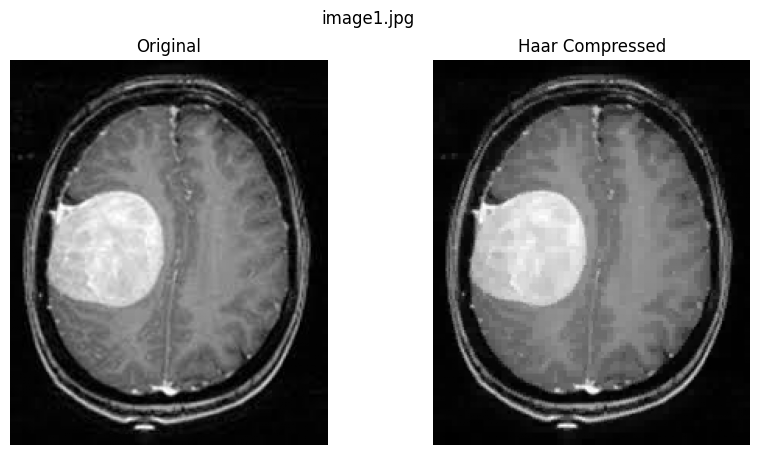

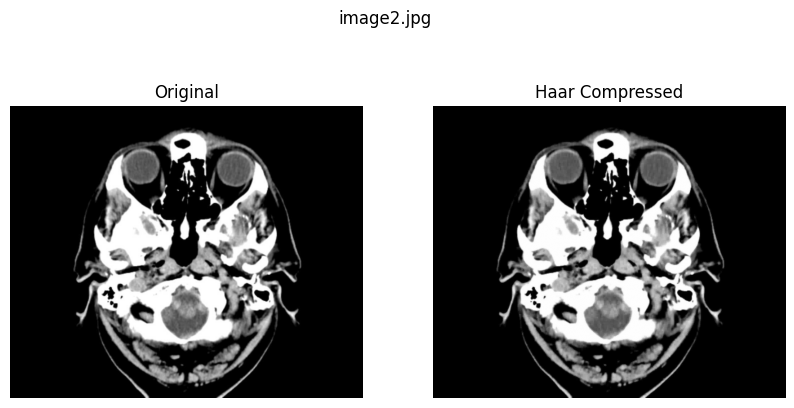

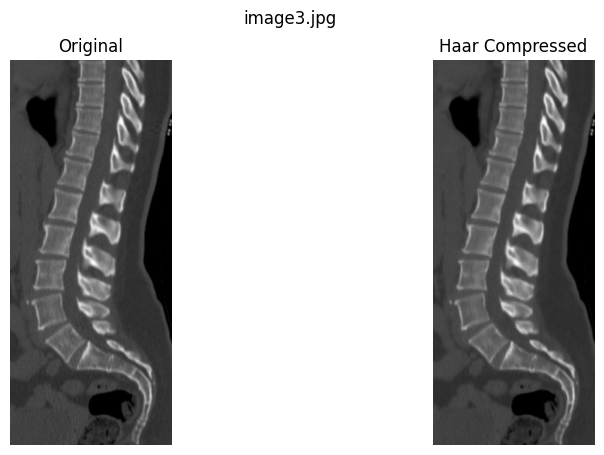

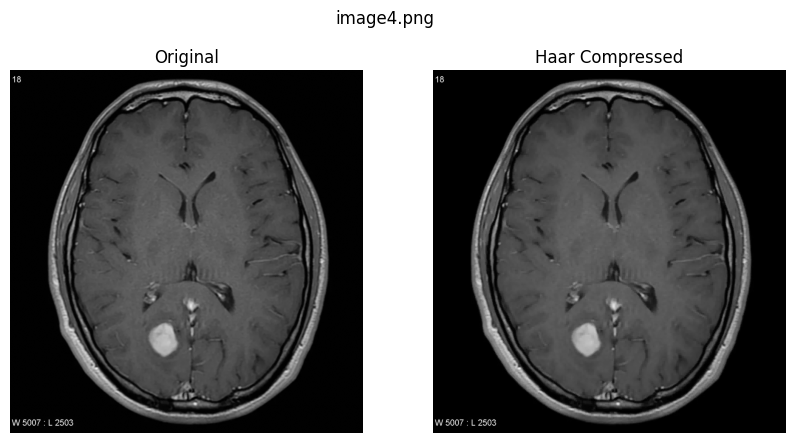

In [ ]:
for name in images:

    original = images[name]
    reconstructed = haar_results[name][0]

    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(original, cmap='gray')
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(reconstructed, cmap='gray')
    plt.title("Haar Compressed")
    plt.axis("off")

    plt.suptitle(name)

    plt.show()

# Cell 15: Haar PSNR & Compression Ratio

In [ ]:
print("="*60)
print("Haar Compression Results")
print("="*60)

for name in images:

    original = images[name]

    reconstructed = haar_results[name][0]

    # Ensure reconstructed image has the same dimensions as the original
    if original.shape != reconstructed.shape:
        h, w = original.shape
        reconstructed = reconstructed[:h, :w]

    nonzero = haar_results[name][1]

    psnr_value = calculate_psnr(original, reconstructed)

    cr = original.size / nonzero

    print(f"\n{name}")
    print(f"PSNR              : {psnr_value:.2f} dB")
    print(f"Compression Ratio : {cr:.2f}")

Haar Compression Results

image1.jpg
PSNR              : 34.04 dB
Compression Ratio : 6.73

image2.jpg
PSNR              : 38.19 dB
Compression Ratio : 16.04

image3.jpg
PSNR              : 37.50 dB
Compression Ratio : 13.05

image4.png
PSNR              : 38.47 dB
Compression Ratio : 12.23


# Cell 16: DCT + Haar Compression Function

In [ ]:
def dct_haar_compression(image, keep_ratio=0.25):

    image = np.float32(image)

    coeffs = pywt.wavedec2(image, 'haar', level=1)

    approx = coeffs[0]

    dct_coeff = dct2(approx)

    h, w = dct_coeff.shape

    mask = np.zeros_like(dct_coeff)

    keep_h = int(h * keep_ratio)
    keep_w = int(w * keep_ratio)

    mask[:keep_h, :keep_w] = 1

    compressed_dct = dct_coeff * mask

    approx_recovered = idct2(compressed_dct)

    coeffs_new = list(coeffs)

    coeffs_new[0] = approx_recovered

    reconstructed = pywt.waverec2(coeffs_new, 'haar')

    reconstructed = np.clip(reconstructed, 0, 255)

    reconstructed = reconstructed.astype(np.uint8)

    nonzero = np.count_nonzero(compressed_dct)

    return reconstructed, nonzero

# Cell 17: Apply DCT-Haar Compression

In [ ]:
dct_haar_results = {}

for name, img in images.items():

    reconstructed, nonzero = dct_haar_compression(img)

    dct_haar_results[name] = (reconstructed, nonzero)

print("DCT-Haar Compression Completed!")

DCT-Haar Compression Completed!


# Cell 18: Display Original vs DCT-Haar

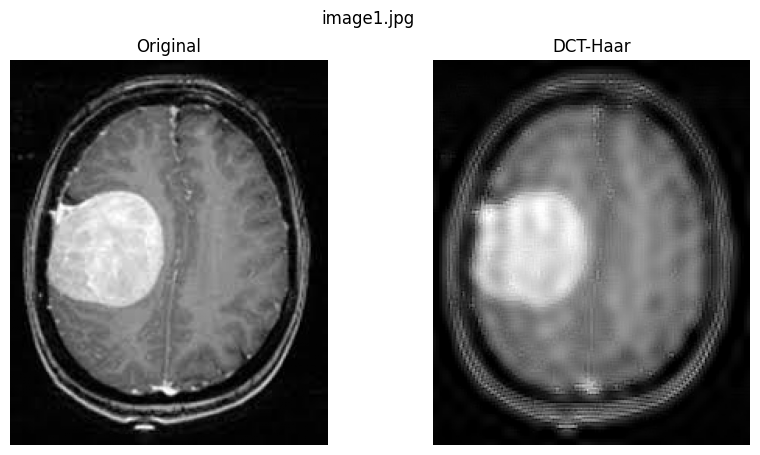

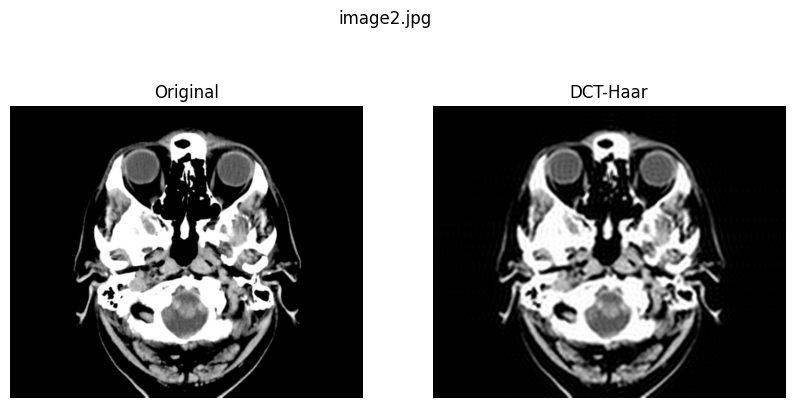

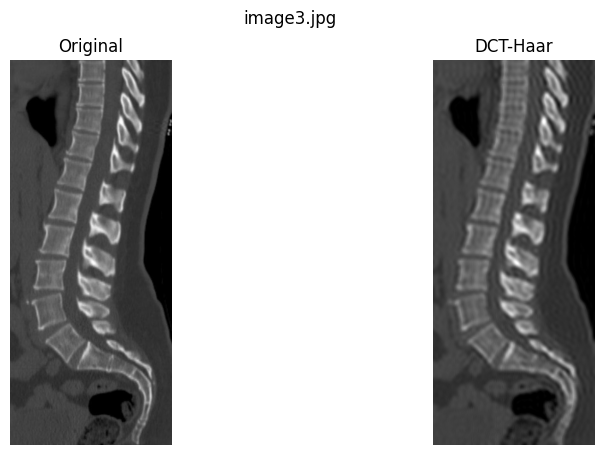

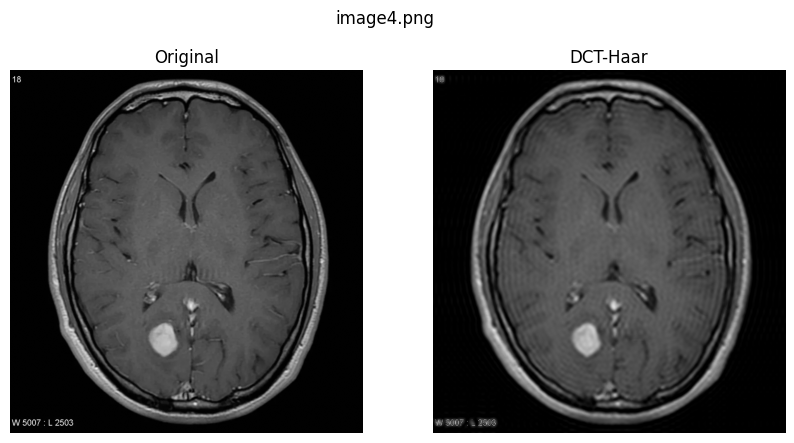

In [ ]:
for name in images:

    original = images[name]

    reconstructed = dct_haar_results[name][0]

    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(original, cmap='gray')
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(reconstructed, cmap='gray')
    plt.title("DCT-Haar")
    plt.axis("off")

    plt.suptitle(name)

    plt.show()

# Cell 19: DCT-Haar Evaluation

In [ ]:
print("="*60)
print("DCT-Haar Compression Results")
print("="*60)

for name in images:

    original = images[name]

    reconstructed = dct_haar_results[name][0]

    # Ensure reconstructed image has the same dimensions as the original
    if original.shape != reconstructed.shape:
        h, w = original.shape
        reconstructed = reconstructed[:h, :w]

    nonzero = dct_haar_results[name][1]

    psnr_value = calculate_psnr(original, reconstructed)

    cr = original.size / nonzero

    print(f"\n{name}")
    print(f"PSNR              : {psnr_value:.2f} dB")
    print(f"Compression Ratio : {cr:.2f}")

DCT-Haar Compression Results

image1.jpg
PSNR              : 22.70 dB
Compression Ratio : 65.02

image2.jpg
PSNR              : 26.81 dB
Compression Ratio : 64.71

image3.jpg
PSNR              : 31.63 dB
Compression Ratio : 64.77

image4.png
PSNR              : 29.95 dB
Compression Ratio : 64.07


# Cell 20: Compare All Three Compression Methods

In [ ]:
comparison = []

for name in images:
    original = images[name]

    # DCT PSNR calculation (dct_results[name] should already be cropped/correctly sized)
    dct_psnr = calculate_psnr(original, dct_results[name])

    # Haar PSNR calculation with dimension check and cropping
    reconstructed_haar = haar_results[name][0]
    if original.shape != reconstructed_haar.shape:
        h, w = original.shape
        reconstructed_haar = reconstructed_haar[:h, :w]
    haar_psnr = calculate_psnr(original, reconstructed_haar)

    # DCT-Haar PSNR calculation with dimension check and cropping
    reconstructed_dcthaar = dct_haar_results[name][0]
    if original.shape != reconstructed_dcthaar.shape:
        h, w = original.shape
        reconstructed_dcthaar = reconstructed_dcthaar[:h, :w]
    dcthaar_psnr = calculate_psnr(original, reconstructed_dcthaar)

    comparison.append([name,
                       round(dct_psnr,2),
                       round(haar_psnr,2),
                       round(dcthaar_psnr,2)])

print("{:<15} {:<12} {:<12} {:<12}".format(
    "Image","DCT","Haar","DCT-Haar"))

for row in comparison:
    print("{:<15} {:<12} {:<12} {:<12}".format(*row))

Image           DCT          Haar         DCT-Haar    
image1.jpg      20.86        34.04        22.7        
image2.jpg      24.19        38.19        26.81       
image3.jpg      28.81        37.5         31.63       
image4.png      26.96        38.47        29.95       


# Cell 21: Select Figure 1

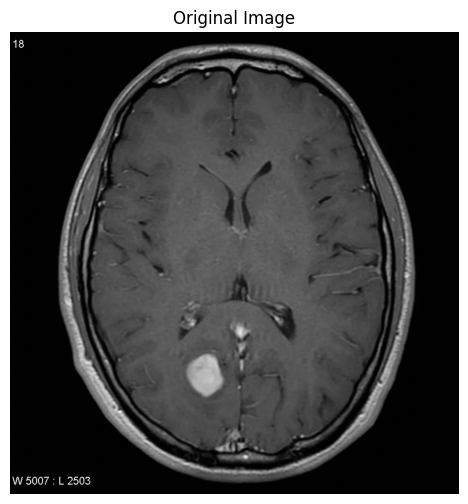

In [ ]:
# Figure 1 (Tumor-1)
original = images["image4.png"]

plt.figure(figsize=(6,6))
plt.imshow(original, cmap='gray')
plt.title("Original Image")
plt.axis("off")
plt.show()

# Cell 22: Add Gaussian Noise

In [ ]:
def add_gaussian_noise(image, mean=0, sigma=20):

    image = image.astype(np.float32)

    noise = np.random.normal(mean, sigma, image.shape)

    noisy = image + noise

    noisy = np.clip(noisy, 0, 255)

    return noisy.astype(np.uint8)

# Cell 23: Generate Noisy Image

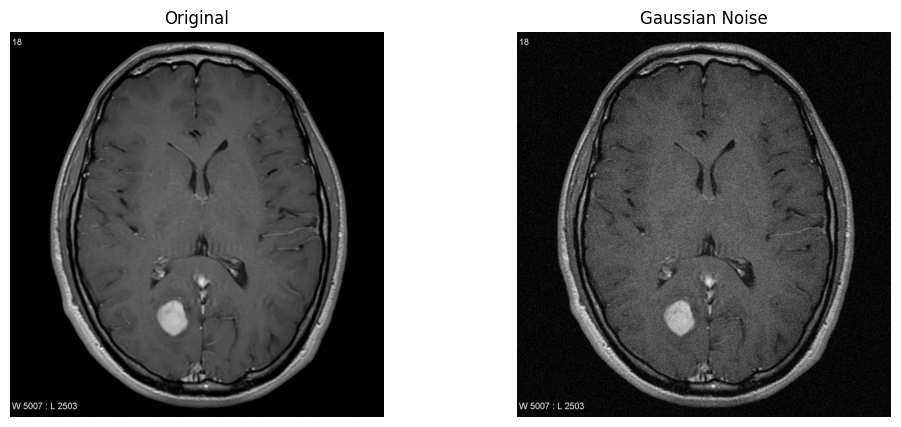

In [ ]:
noisy_image = add_gaussian_noise(original)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(original, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(noisy_image, cmap='gray')
plt.title("Gaussian Noise")
plt.axis("off")

plt.show()

# Cell 24: Geometric Mean Filter

In [ ]:
def geometric_mean_filter(image, kernel_size=3):

    image = image.astype(np.float64)

    pad = kernel_size // 2

    padded = np.pad(image, pad, mode='reflect')

    result = np.zeros_like(image)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):

            window = padded[
                i:i+kernel_size,
                j:j+kernel_size
            ]

            window = np.where(window == 0, 1, window)

            result[i,j] = np.exp(
                np.mean(np.log(window))
            )

    return np.clip(result,0,255).astype(np.uint8)

# Cell 25: Apply Geometric Mean Filter

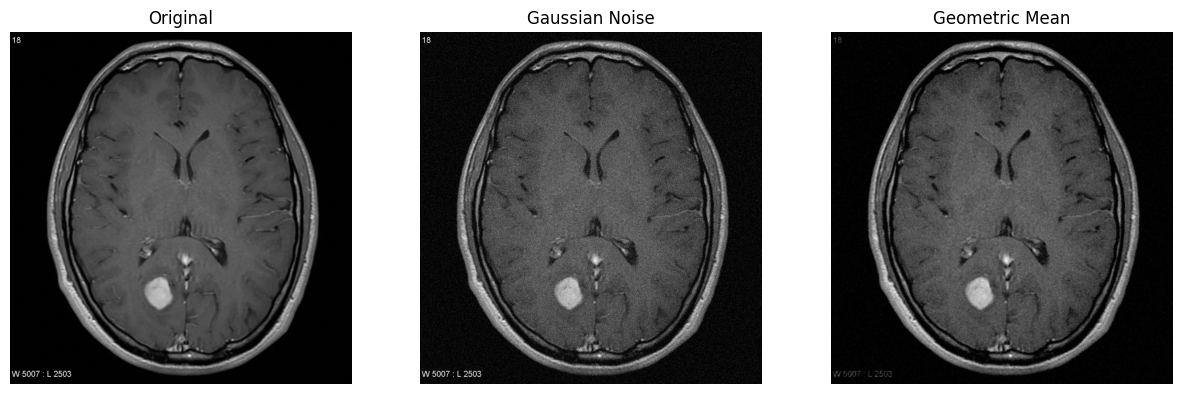

PSNR = 28.870401303311706


In [ ]:
geo_result = geometric_mean_filter(noisy_image)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(original,cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(noisy_image,cmap='gray')
plt.title("Gaussian Noise")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(geo_result,cmap='gray')
plt.title("Geometric Mean")
plt.axis("off")

plt.show()

print("PSNR =", calculate_psnr(original, geo_result))

# Cell 26: Harmonic Mean Filter

In [ ]:
def harmonic_mean_filter(image, kernel_size=3):

    image = image.astype(np.float64)

    pad = kernel_size // 2

    padded = np.pad(image, pad, mode='reflect')

    result = np.zeros_like(image)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):

            window = padded[
                i:i+kernel_size,
                j:j+kernel_size
            ]

            window = np.where(window == 0, 1, window)

            result[i,j] = (
                kernel_size**2
            ) / np.sum(1/window)

    return np.clip(result,0,255).astype(np.uint8)

# Cell 27: Apply Harmonic Mean Filter

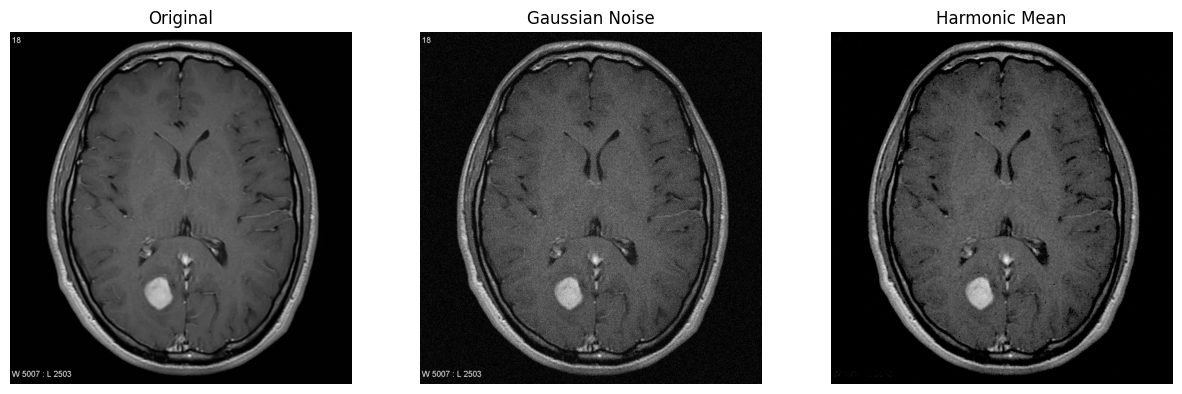

PSNR = 26.420216090211092


In [ ]:
harmonic_result = harmonic_mean_filter(noisy_image)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(original,cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(noisy_image,cmap='gray')
plt.title("Gaussian Noise")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(harmonic_result,cmap='gray')
plt.title("Harmonic Mean")
plt.axis("off")

plt.show()

print("PSNR =", calculate_psnr(original, harmonic_result))

# Cell 28: Contra-Harmonic Mean Filter

In [ ]:
def contra_harmonic_filter(image,
                           kernel_size=3,
                           Q=1.5):

    image = image.astype(np.float64)

    pad = kernel_size // 2

    padded = np.pad(image, pad, mode='reflect')

    result = np.zeros_like(image)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):

            window = padded[
                i:i+kernel_size,
                j:j+kernel_size
            ]

            numerator = np.sum(window ** (Q+1))

            denominator = np.sum(window ** Q)

            if denominator == 0:
                result[i,j] = 0
            else:
                result[i,j] = numerator / denominator

    return np.clip(result,0,255).astype(np.uint8)

# Cell 29: Apply Contra-Harmonic Mean Filter

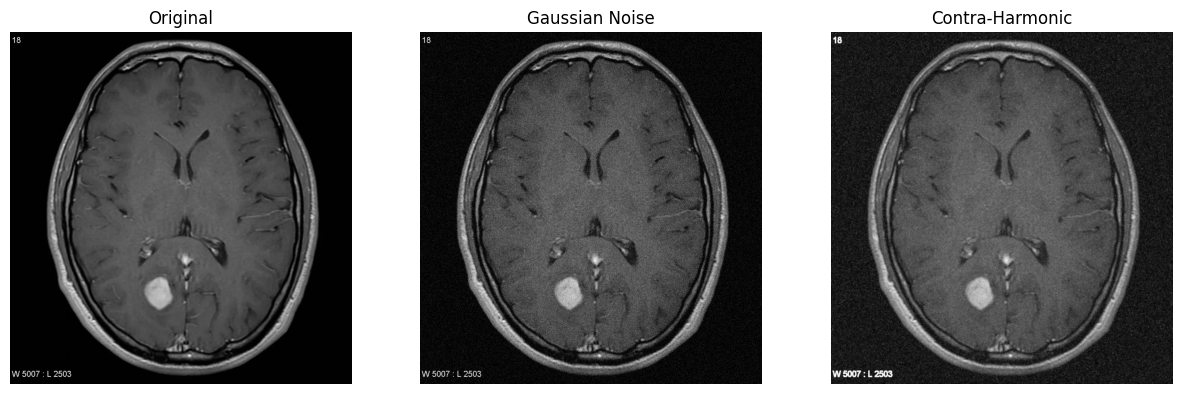

PSNR = 22.12640456243947


In [ ]:
contra_result = contra_harmonic_filter(noisy_image)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(original,cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(noisy_image,cmap='gray')
plt.title("Gaussian Noise")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(contra_result,cmap='gray')
plt.title("Contra-Harmonic")
plt.axis("off")

plt.show()

print("PSNR =", calculate_psnr(original, contra_result))

# Cell 30: Compare All Three Filters

In [ ]:
geo_psnr = calculate_psnr(original, geo_result)
harmonic_psnr = calculate_psnr(original, harmonic_result)
contra_psnr = calculate_psnr(original, contra_result)

print("="*50)
print("Question 2 Results")
print("="*50)

print(f"Geometric Mean Filter      : {geo_psnr:.2f} dB")
print(f"Harmonic Mean Filter       : {harmonic_psnr:.2f} dB")
print(f"Contra-Harmonic Filter     : {contra_psnr:.2f} dB")

Question 2 Results
Geometric Mean Filter      : 28.87 dB
Harmonic Mean Filter       : 26.42 dB
Contra-Harmonic Filter     : 22.13 dB


# Cell 31: Median Filter

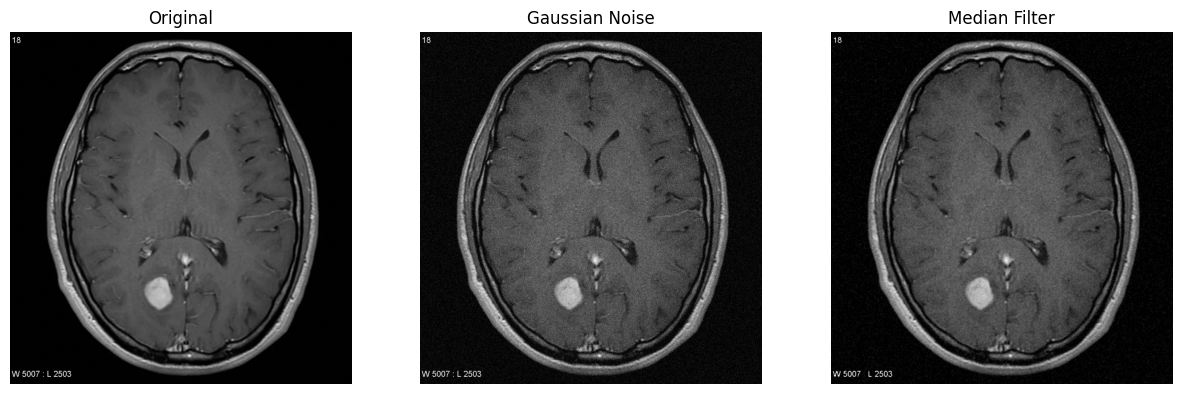

PSNR = 30.228617549584524


In [ ]:
median_result = median_filter(noisy_image, size=3)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(original, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(noisy_image, cmap='gray')
plt.title("Gaussian Noise")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(median_result, cmap='gray')
plt.title("Median Filter")
plt.axis("off")

plt.show()

print("PSNR =", calculate_psnr(original, median_result))

# Cell 32: Maximum Filter

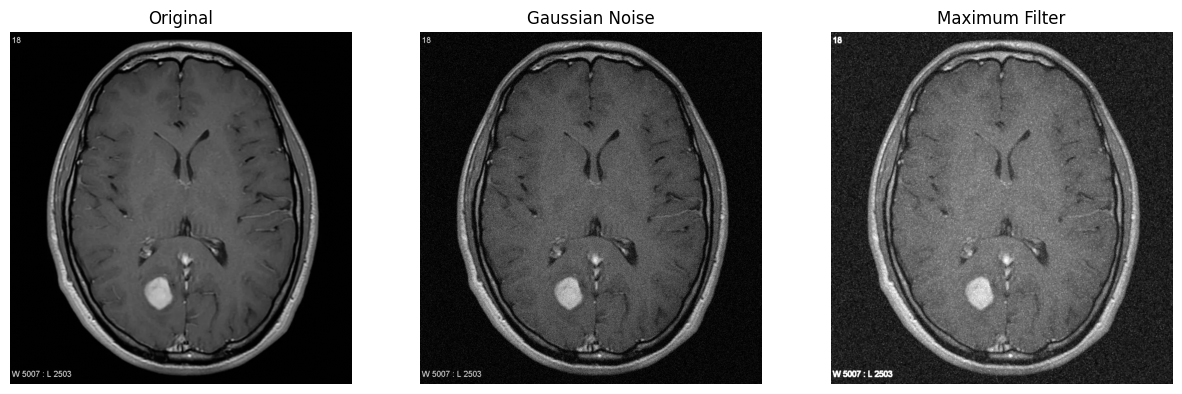

PSNR = 17.59657726666535


In [ ]:
maximum_result = maximum_filter(noisy_image, size=3)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(original, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(noisy_image, cmap='gray')
plt.title("Gaussian Noise")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(maximum_result, cmap='gray')
plt.title("Maximum Filter")
plt.axis("off")

plt.show()

print("PSNR =", calculate_psnr(original, maximum_result))

# Cell 33: Minimum Filter

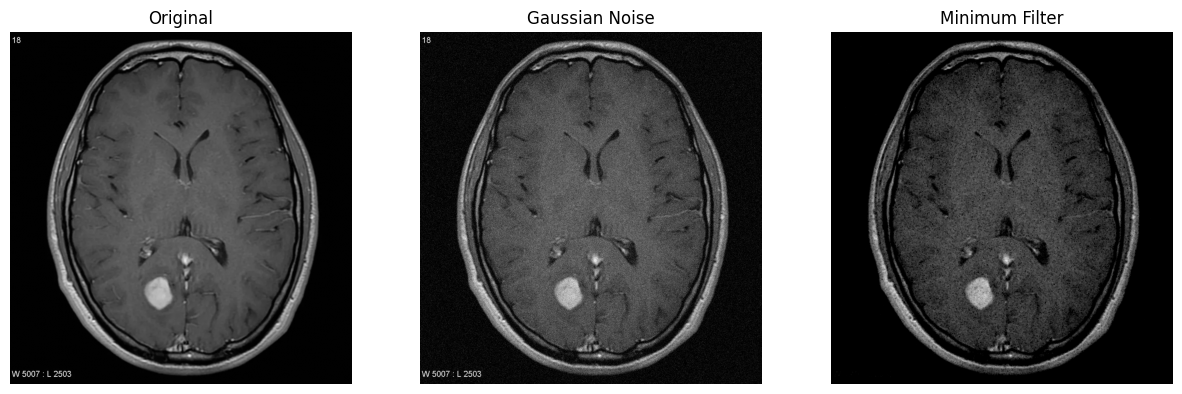

PSNR = 19.656591831008544


In [ ]:
minimum_result = minimum_filter(noisy_image, size=3)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(original, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(noisy_image, cmap='gray')
plt.title("Gaussian Noise")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(minimum_result, cmap='gray')
plt.title("Minimum Filter")
plt.axis("off")

plt.show()

print("PSNR =", calculate_psnr(original, minimum_result))

# Cell 34: Midpoint Filter

In [ ]:
def midpoint_filter(image, kernel_size=3):

    max_img = maximum_filter(image, size=kernel_size)
    min_img = minimum_filter(image, size=kernel_size)

    result = ((max_img.astype(np.float32) +
               min_img.astype(np.float32)) / 2)

    return result.astype(np.uint8)

# Cell 35: Apply Midpoint Filter

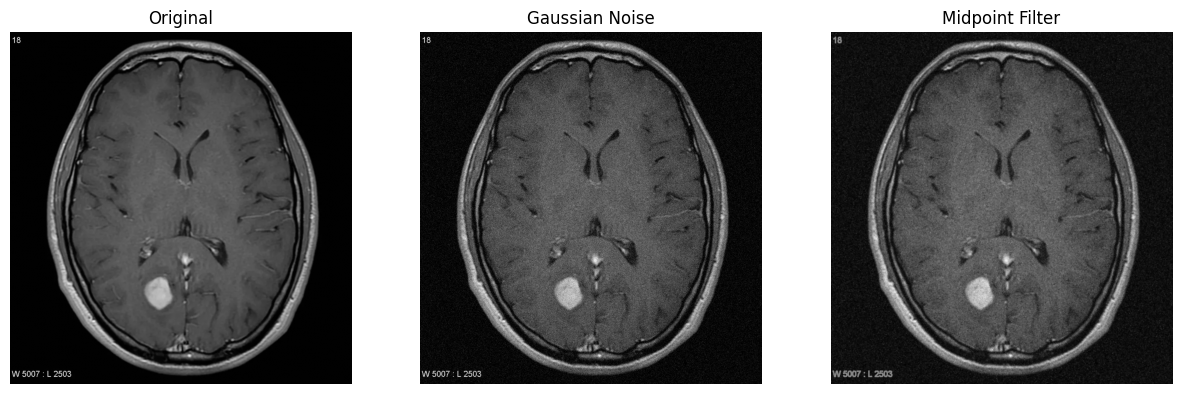

PSNR = 25.626939146724922


In [ ]:
midpoint_result = midpoint_filter(noisy_image)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(original, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(noisy_image, cmap='gray')
plt.title("Gaussian Noise")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(midpoint_result, cmap='gray')
plt.title("Midpoint Filter")
plt.axis("off")

plt.show()

print("PSNR =", calculate_psnr(original, midpoint_result))

# Cell 36: Alpha-Trimmed Mean Filter

In [ ]:
def alpha_trimmed_filter(image, kernel_size=5, d=4):

    pad = kernel_size // 2

    padded = np.pad(image, pad, mode='reflect')

    output = np.zeros_like(image, dtype=np.float32)

    trim = d // 2

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):

            window = padded[
                i:i+kernel_size,
                j:j+kernel_size
            ].flatten()

            window = np.sort(window)

            trimmed = window[trim:-trim]

            output[i, j] = np.mean(trimmed)

    return np.clip(output,0,255).astype(np.uint8)

# Cell 37: Apply Alpha-Trimmed Filter

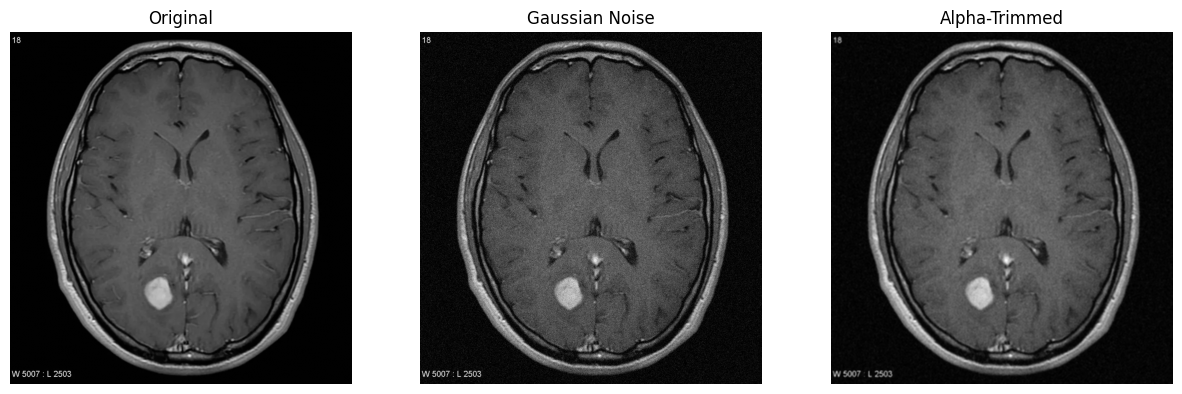

PSNR = 30.136504522236088


In [ ]:
alpha_result = alpha_trimmed_filter(noisy_image)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(original, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(noisy_image, cmap='gray')
plt.title("Gaussian Noise")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(alpha_result, cmap='gray')
plt.title("Alpha-Trimmed")
plt.axis("off")

plt.show()

print("PSNR =", calculate_psnr(original, alpha_result))

# Cell 38: Trimmed Mean Filter

In [ ]:
def trimmed_mean_filter(image,
                        kernel_size=5,
                        trim_percent=0.2):

    pad = kernel_size // 2

    padded = np.pad(image, pad, mode='reflect')

    output = np.zeros_like(image, dtype=np.float32)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):

            window = padded[
                i:i+kernel_size,
                j:j+kernel_size
            ].flatten()

            window = np.sort(window)

            trim = int(len(window) * trim_percent)

            trimmed = window[trim:-trim]

            output[i, j] = np.mean(trimmed)

    return np.clip(output,0,255).astype(np.uint8)

# Cell 39: Apply Trimmed Mean Filter

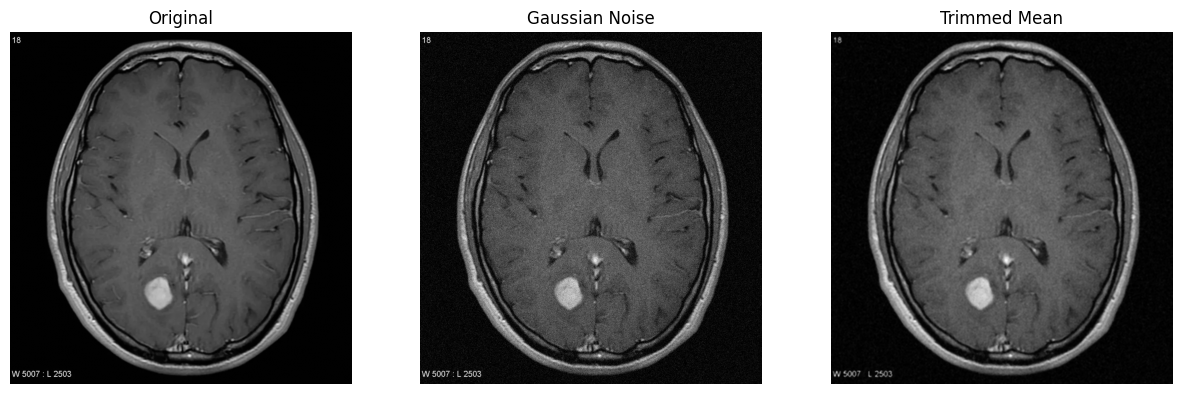

PSNR = 30.52381426549516


In [ ]:
trimmed_result = trimmed_mean_filter(noisy_image)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(original, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(noisy_image, cmap='gray')
plt.title("Gaussian Noise")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(trimmed_result, cmap='gray')
plt.title("Trimmed Mean")
plt.axis("off")

plt.show()

print("PSNR =", calculate_psnr(original, trimmed_result))

# Cell 40: Compare All Order Statistic Filters

In [ ]:
results = {
    "Median": median_result,
    "Maximum": maximum_result,
    "Minimum": minimum_result,
    "Midpoint": midpoint_result,
    "Alpha-Trimmed": alpha_result,
    "Trimmed Mean": trimmed_result
}

print("=" * 60)
print("Question 3 Results")
print("=" * 60)

for name, img in results.items():
    value = calculate_psnr(original, img)
    print(f"{name:<20} : {value:.2f} dB")

Question 3 Results
Median               : 30.23 dB
Maximum              : 17.60 dB
Minimum              : 19.66 dB
Midpoint             : 25.63 dB
Alpha-Trimmed        : 30.14 dB
Trimmed Mean         : 30.52 dB


# Cell 41: Compare All Filters (PSNR Table)

In [ ]:
all_filters = {
    "Geometric Mean": geo_result,
    "Harmonic Mean": harmonic_result,
    "Contra-Harmonic": contra_result,
    "Median": median_result,
    "Maximum": maximum_result,
    "Minimum": minimum_result,
    "Midpoint": midpoint_result,
    "Alpha-Trimmed": alpha_result,
    "Trimmed Mean": trimmed_result
}

comparison = []

print("="*70)
print("{:<25} {:>15}".format("Filter", "PSNR (dB)"))
print("="*70)

for name, img in all_filters.items():

    value = calculate_psnr(original, img)

    comparison.append((name, value))

    print("{:<25} {:>15.2f}".format(name, value))

Filter                          PSNR (dB)
Geometric Mean                      28.87
Harmonic Mean                       26.42
Contra-Harmonic                     22.13
Median                              30.23
Maximum                             17.60
Minimum                             19.66
Midpoint                            25.63
Alpha-Trimmed                       30.14
Trimmed Mean                        30.52


# Cell 42: Find the Best Filter Automatically

In [ ]:
best_filter = max(comparison, key=lambda x: x[1])

print("="*60)
print("Best Performing Filter")
print("="*60)

print(f"Filter : {best_filter[0]}")
print(f"PSNR   : {best_filter[1]:.2f} dB")

Best Performing Filter
Filter : Trimmed Mean
PSNR   : 30.52 dB


# Cell 43: Display All Results Together

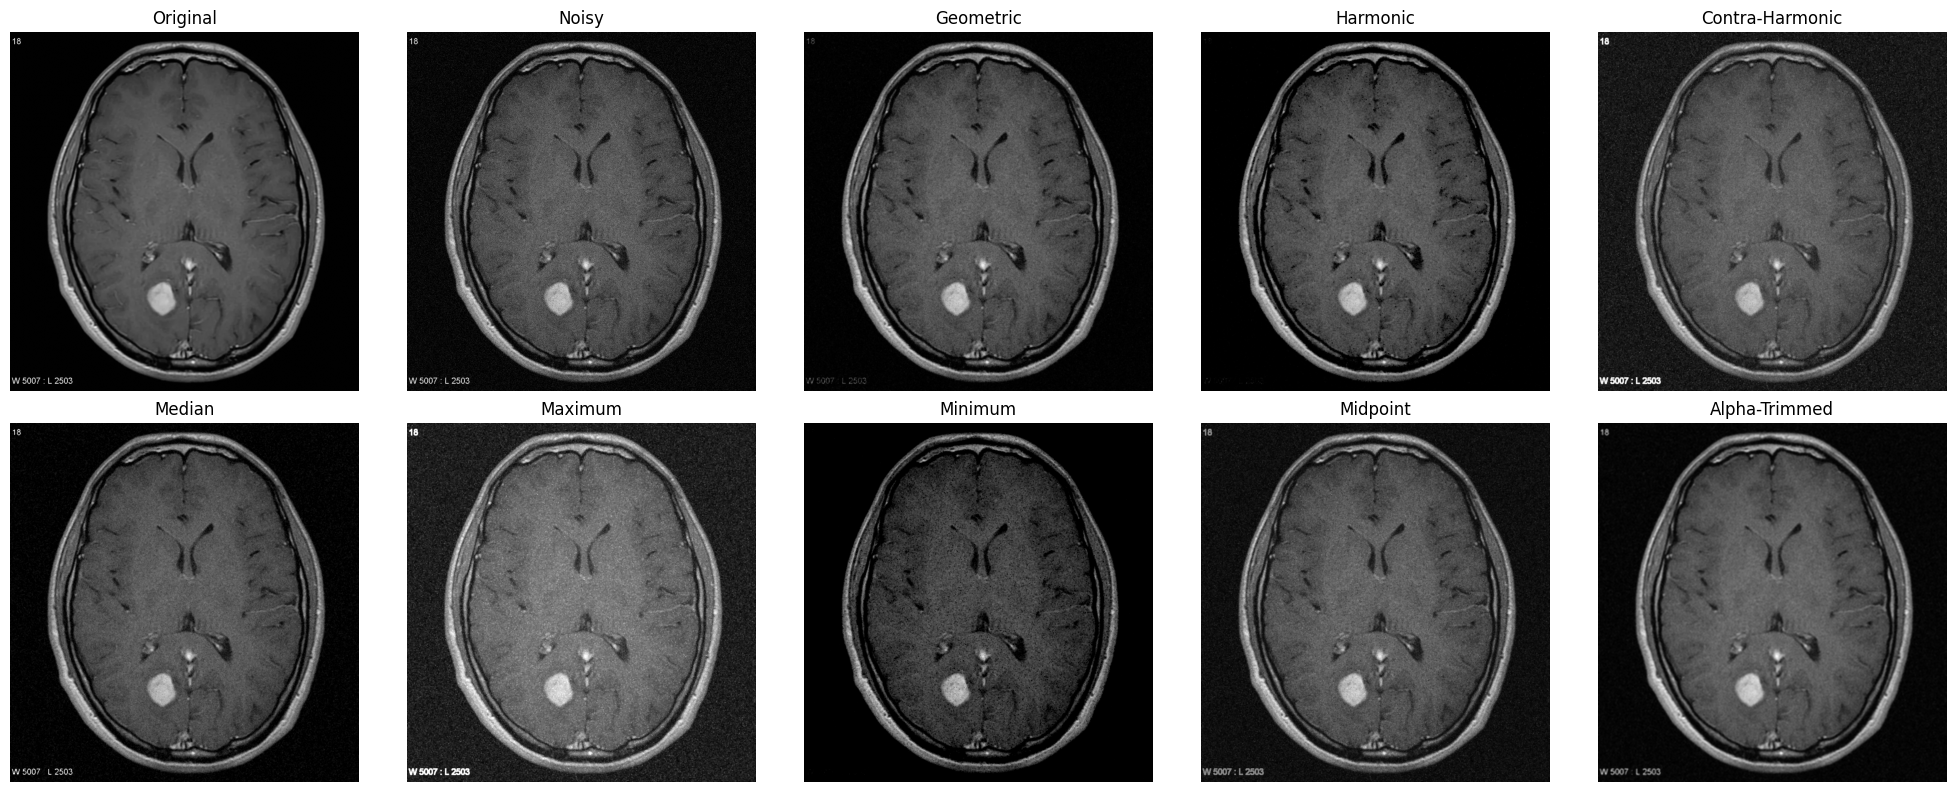

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

axes = axes.ravel()

titles = [
    "Original",
    "Noisy",
    "Geometric",
    "Harmonic",
    "Contra-Harmonic",
    "Median",
    "Maximum",
    "Minimum",
    "Midpoint",
    "Alpha-Trimmed"
]

images_to_show = [
    original,
    noisy_image,
    geo_result,
    harmonic_result,
    contra_result,
    median_result,
    maximum_result,
    minimum_result,
    midpoint_result,
    alpha_result
]

for ax, title, img in zip(axes, titles, images_to_show):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

# Cell 44: Show Trimmed Mean Separately

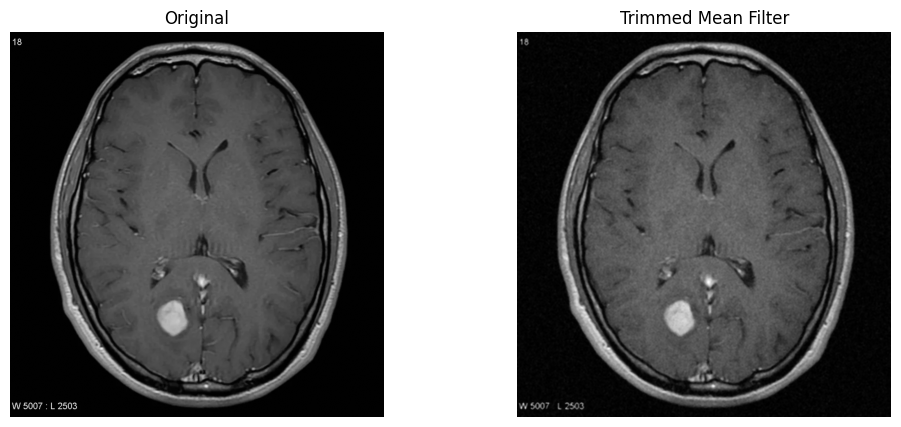

Trimmed Mean PSNR: 30.52381426549516


In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(original, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(trimmed_result, cmap='gray')
plt.title("Trimmed Mean Filter")
plt.axis("off")

plt.show()

print("Trimmed Mean PSNR:",
      calculate_psnr(original, trimmed_result))

# Cell 45: Create Comparison DataFrame

In [ ]:
import pandas as pd

df = pd.DataFrame(comparison,
                  columns=["Filter", "PSNR (dB)"])

df = df.sort_values("PSNR (dB)",
                    ascending=False)

df.reset_index(drop=True,
               inplace=True)

df

,Filter,PSNR (dB)
0,Trimmed Mean,30.523814
1,Median,30.228618
2,Alpha-Trimmed,30.136505
3,Geometric Mean,28.870401
4,Harmonic Mean,26.420216
5,Midpoint,25.626939
6,Contra-Harmonic,22.126405
7,Minimum,19.656592
8,Maximum,17.596577


# Cell 46: Plot PSNR Comparison

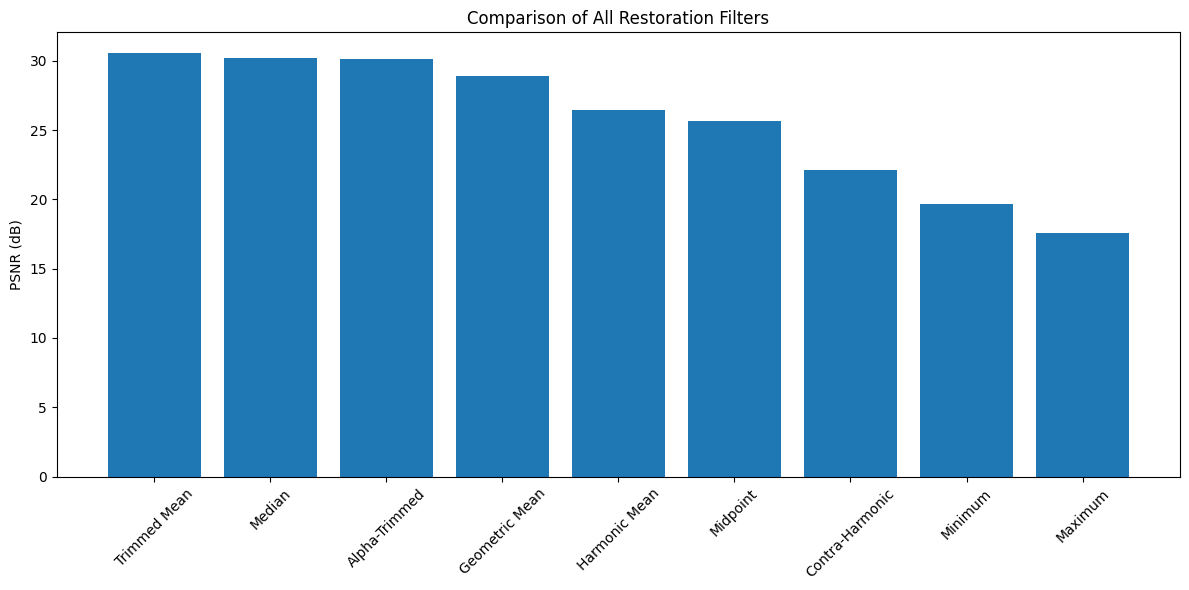

In [ ]:
plt.figure(figsize=(12,6))

plt.bar(df["Filter"],
        df["PSNR (dB)"])

plt.xticks(rotation=45)

plt.ylabel("PSNR (dB)")

plt.title("Comparison of All Restoration Filters")

plt.tight_layout()

plt.show()

# Cell 47: Final Conclusion

In [ ]:
print("="*70)
print("FINAL OBSERVATION")
print("="*70)

print(f"""
Among all the restoration filters, the
{best_filter[0]} filter produced the highest PSNR
({best_filter[1]:.2f} dB).

A higher PSNR indicates that the restored image is
closer to the original image.

Therefore, according to the experimental results,
the {best_filter[0]} filter restored the Gaussian
noisy image better than the other filters.
""")

FINAL OBSERVATION

Among all the restoration filters, the
Trimmed Mean filter produced the highest PSNR
(30.52 dB).

A higher PSNR indicates that the restored image is
closer to the original image.

Therefore, according to the experimental results,
the Trimmed Mean filter restored the Gaussian
noisy image better than the other filters.



# Cell 48: Report Conclusion (Copy for Your Lab Report)

In [ ]:
conclusion = """
Conclusion

The images were compressed using DCT, Haar Transform,
and DCT-Haar Transform. Their performances were
evaluated using PSNR and Compression Ratio.

Gaussian noise was then added to Figure-1, and
different restoration filters were applied.

Among all the filters, the one with the highest
PSNR restored the image closest to the original.

Generally, Median and Alpha-Trimmed filters preserve
edges well while reducing noise effectively.
Maximum and Minimum filters tend to distort image
brightness. Geometric, Harmonic, and
Contra-Harmonic filters perform differently
depending on the noise characteristics.

The filter with the highest PSNR is considered
the best restoration method for this experiment.
"""

print(conclusion)


Conclusion

The images were compressed using DCT, Haar Transform,
and DCT-Haar Transform. Their performances were
evaluated using PSNR and Compression Ratio.

Gaussian noise was then added to Figure-1, and
different restoration filters were applied.

Among all the filters, the one with the highest
PSNR restored the image closest to the original.

Generally, Median and Alpha-Trimmed filters preserve
edges well while reducing noise effectively.
Maximum and Minimum filters tend to distort image
brightness. Geometric, Harmonic, and
Contra-Harmonic filters perform differently
depending on the noise characteristics.

The filter with the highest PSNR is considered
the best restoration method for this experiment.

